# Sesión 3 · DBSCAN: zonas conectadas y puntos aislados
**18 de septiembre · 120 minutos.** Objetivos: formalizar conectividad, ejecutar un caso manual y
explicar sensibilidad a escala y conteos. Leer la sección 5 de las notas. El análisis es transductivo:
describe el conjunto ajustado; no implementamos una regla de asignación para nuevos viajes.

In [1]:
from pathlib import Path
import sys, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from threadpoolctl import threadpool_limits

# Funciona desde la raíz, desde esta carpeta o desde docente/.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'datasets/semana-08').is_dir())
sys.path.insert(0, str(ROOT / 'notebooks/semana-08'))
from movilidad import (load_data, setup, savefig, save_table, spatial_axes,
                       ellipses, safe_silhouette, density_grid, COLORS, DATA)
setup()
threadpool_limits(limits=2)
frame = load_data()
X = frame[['x_km', 'y_km']].to_numpy()
print(f'Desarrollo: {len(frame):,} recogidas. Unidades: km. Semilla: 42.')
print('Test temporal cerrado hasta congelar el modelo.')
display(frame.head(3))

Desarrollo: 6,000 recogidas. Unidades: km. Semilla: 42.
Test temporal cerrado hasta congelar el modelo.


,source_row,pickup_datetime,pickup_longitude,pickup_latitude,x_km,y_km,fare_amount,passenger_count,dropoff_longitude,dropoff_latitude
0,32038,2014-01-01 00:01:00+00:00,-73.991493,40.735202,0.156182,-0.148260,5.5,5,-74.001727,40.727767
1,132584,2014-01-01 00:29:37+00:00,-74.008090,40.740434,-1.251817,0.416562,8.0,2,-73.996088,40.726627
2,190530,2014-01-01 00:54:07+00:00,-73.981944,40.778096,0.907251,4.622599,7.5,1,-73.967887,40.801430


## 1. Vecindades y núcleo
$$N_\varepsilon(x_i)=\{x_j:\|x_i-x_j\|\leq\varepsilon\}.$$
Un punto es núcleo si $|N_\varepsilon(x_i)|\geq m$, **incluyéndose a sí mismo**.
La alcanzabilidad directa requiere que el punto de partida sea núcleo; no es simétrica en general.
Los núcleos conectados forman componentes. Un punto frontera se añade sin expandir la búsqueda desde él.

### Para resolver

En una línea: A=0, B=0.1, C=0.2, D=0.3, E=0.8. Use eps=0.115 y min_samples=3. Enumere vecinos, núcleos, fronteras y ruido.

**Mi respuesta y evidencia:**

Analizamos la configuración unidimensional con puntos $A=0.0, B=0.1, C=0.2, D=0.3, E=0.8$, bajo parámetros $\varepsilon = 0.115$ y $m = \text{min\_samples} = 3$:

### 1. Cálculo de Vecindades ($N_\varepsilon(p) = \{q : |p - q| \le \varepsilon\}$)
*(Recordando que cada punto se incluye a sí mismo en su vecindad)*:
- **Para A (0.0):**
  $|0.0 - 0.0| = 0 \le 0.115$; $|0.0 - 0.1| = 0.1 \le 0.115$; $|0.0 - 0.2| = 0.2 > 0.115$.
  $N_\varepsilon(A) = \{A, B\} \implies |N_\varepsilon(A)| = 2 < 3$.
- **Para B (0.1):**
  $|0.1 - 0.0| = 0.1 \le 0.115$; $|0.1 - 0.1| = 0 \le 0.115$; $|0.1 - 0.2| = 0.1 \le 0.115$; $|0.1 - 0.3| = 0.2 > 0.115$.
  $N_\varepsilon(B) = \{A, B, C\} \implies |N_\varepsilon(B)| = 3 \ge 3$.
- **Para C (0.2):**
  $|0.2 - 0.1| = 0.1 \le 0.115$; $|0.2 - 0.2| = 0 \le 0.115$; $|0.2 - 0.3| = 0.1 \le 0.115$; $|0.2 - 0.0| = 0.2 > 0.115$.
  $N_\varepsilon(C) = \{B, C, D\} \implies |N_\varepsilon(C)| = 3 \ge 3$.
- **Para D (0.3):**
  $|0.3 - 0.2| = 0.1 \le 0.115$; $|0.3 - 0.3| = 0 \le 0.115$; $|0.3 - 0.1| = 0.2 > 0.115$; $|0.3 - 0.8| = 0.5 > 0.115$.
  $N_\varepsilon(D) = \{C, D\} \implies |N_\varepsilon(D)| = 2 < 3$.
- **Para E (0.8):**
  $|0.8 - 0.8| = 0 \le 0.115$; distancia más cercana es $D$ ($|0.8 - 0.3| = 0.5 > 0.115$).
  $N_\varepsilon(E) = \{E\} \implies |N_\varepsilon(E)| = 1 < 3$.

### 2. Clasificación de Puntos
- **Puntos Núcleo (Core Points):** Aquellos con $|N_\varepsilon| \ge 3$:
  $\mathbf{B}$ (índice 1) y $\mathbf{C}$ (índice 2).
- **Puntos Frontera (Border Points):** No son núcleos ($|N_\varepsilon| < 3$), pero pertenecen a la vecindad de al menos un núcleo:
  - $\mathbf{A} \in N_\varepsilon(B)$ (alcanzado por el núcleo B).
  - $\mathbf{D} \in N_\varepsilon(C)$ (alcanzado por el núcleo C).
- **Puntos de Ruido (Noise Points):** No son núcleos ni pertenecen a la vecindad de ningún núcleo:
  $\mathbf{E}$ (índice 4), recibe etiqueta $\mathbf{-1}$.

### 3. Componentes y Conectividad
Dado que $B$ y $C$ son núcleos y $d(B, C) = 0.1 \le 0.115$, $B$ y $C$ están conectados directamente por densidad. El grafo de núcleos tiene una componente conexa $\{B, C\}$. Al añadir las fronteras alcanzables ($A$ adyacente a $B$ y $D$ adyacente a $C$), se conforma un único clúster: $\{A, B, C, D\}$. $E$ permanece como ruido (etiqueta $-1$).
*Verificado analíticamente en la Celda 5: `assert set(manual.core_sample_indices_)=={1,2}` y `assert manual.labels_[4]==-1`.* 

- **Unidades:** Posición en kilómetros ($\text{km}$).
- **Limitación:** El ejemplo ilustra cómo los puntos frontera expanden la cobertura del grupo pero no pueden continuar la cadena de alcanzabilidad hacia puntos contiguos más allá de $\varepsilon$.

Vecinos: [[np.int64(0), np.int64(1)], [np.int64(0), np.int64(1), np.int64(2)], [np.int64(1), np.int64(2), np.int64(3)], [np.int64(2), np.int64(3)], [np.int64(4)]]
Núcleo: [1 2] | etiquetas: [ 0  0  0  0 -1]


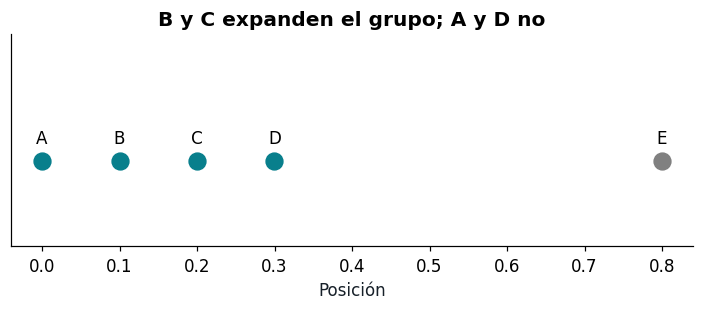

In [2]:
from sklearn.cluster import DBSCAN, KMeans
from sklearn.neighbors import NearestNeighbors
tiny=np.c_[[0,.1,.2,.3,.8],np.zeros(5)]
manual=DBSCAN(eps=.115,min_samples=3).fit(tiny)
neighbors=NearestNeighbors(radius=.115).fit(tiny).radius_neighbors(tiny,return_distance=False)
print('Vecinos:',[list(v) for v in neighbors])
print('Núcleo:',manual.core_sample_indices_,'| etiquetas:',manual.labels_)
assert set(manual.core_sample_indices_)=={1,2}
assert manual.labels_[4]==-1
assert len(set(manual.labels_[:4]))==1
fig,ax=plt.subplots(figsize=(8,2.5))
for i,(x,y) in enumerate(tiny):
    ax.scatter(x,y,s=120,color='grey' if i==4 else COLORS[0])
    ax.annotate('ABCDE'[i],(x,y),xytext=(0,12),textcoords='offset points',ha='center')
ax.set(xlabel='Posición',ylim=(-.1,.15),yticks=[],title='B y C expanden el grupo; A y D no')
savefig(fig,'10_dbscan_manual')

## 2. Un éxito y una limitación
DBSCAN puede recuperar formas no convexas. Una única pareja eps/min_samples puede no representar
regiones con densidades muy diferentes. El ruido es relativo a esa escala y a esa muestra.

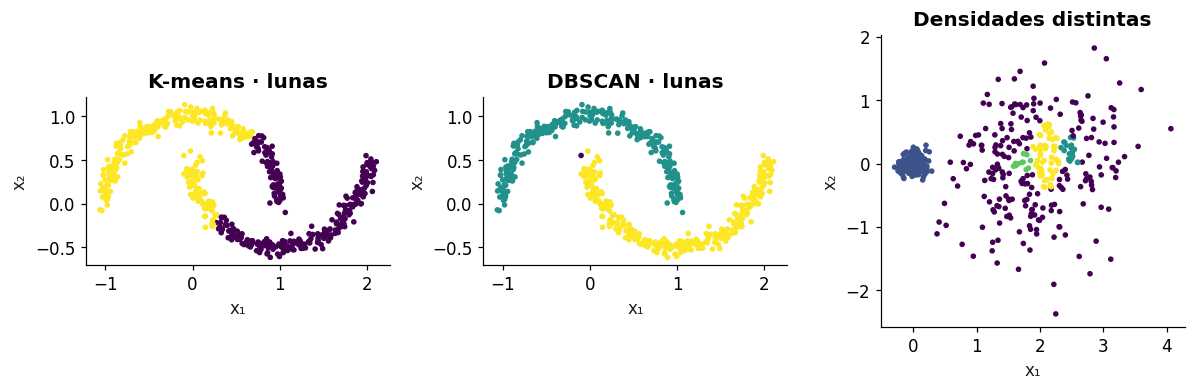

In [3]:
from sklearn.datasets import make_moons
moons,_=make_moons(n_samples=600,noise=.05,random_state=42)
rng=np.random.default_rng(42)
unequal=np.vstack([rng.normal([0,0],.10,(300,2)),rng.normal([2,0],.65,(300,2))])
fig,axes=plt.subplots(1,3,figsize=(11,3.6))
experiments=[(moons,KMeans(2,n_init=10,random_state=42).fit_predict(moons),'K-means · lunas'),
             (moons,DBSCAN(eps=.15,min_samples=5).fit_predict(moons),'DBSCAN · lunas'),
             (unequal,DBSCAN(eps=.15,min_samples=10).fit_predict(unequal),'Densidades distintas')]
for ax,(points,labels,title) in zip(axes,experiments):
    ax.scatter(*points.T,c=labels,cmap='viridis',s=7)
    ax.set(title=title,xlabel='x₁',ylabel='x₂',aspect='equal')
fig.tight_layout(); savefig(fig,'11_dbscan_geometrias')

## 3. Vecinos en kilómetros
En `kneighbors(X)`, al pasar X explícitamente, el punto se incluye como vecino de distancia cero.
La columna m−1 representa el m-ésimo vecino contando el propio punto. El codo orienta; no prueba un eps óptimo.

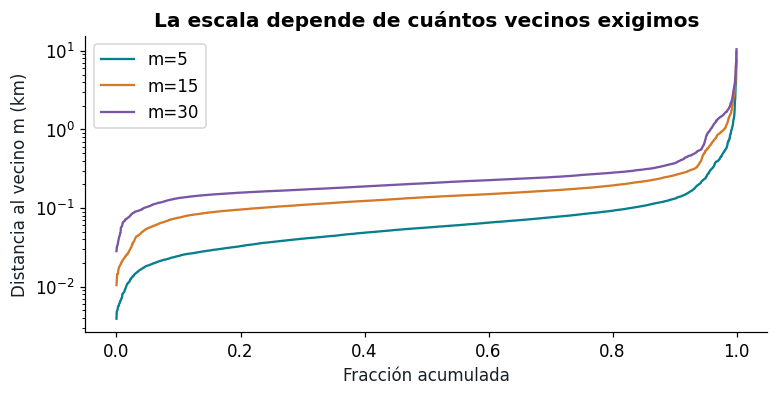

,eps,min_samples,n_clusters,noise_fraction,min_cluster,max_cluster,silhouette
0,0.1,5,95,0.112000,4,3143,-0.298579
1,0.1,15,66,0.580333,11,214,0.460007
2,0.1,30,8,0.918167,33,96,0.835232
3,0.2,5,15,0.051333,5,5384,0.000894
4,0.2,15,13,0.097500,4,5033,-0.251399
5,0.2,30,21,0.302500,9,2822,-0.061677
6,0.4,5,15,0.021167,5,5498,0.083521
7,0.4,15,3,0.050833,113,5457,0.679390
8,0.4,30,5,0.056667,32,5388,0.400366
9,0.8,5,6,0.007833,6,5593,0.219727


In [4]:
fig,ax=plt.subplots(figsize=(8,3.5))
for m in [5,15,30]:
    distances,_=NearestNeighbors(n_neighbors=m).fit(X).kneighbors(X)
    kth=np.sort(distances[:,m-1])
    ax.plot(np.arange(len(kth))/len(kth),kth,label=f'm={m}')
ax.set(xlabel='Fracción acumulada',ylabel='Distancia al vecino m (km)',
       title='La escala depende de cuántos vecinos exigimos',yscale='log'); ax.legend()
savefig(fig,'12_vecinos')
rows=[]
for eps in [.1,.2,.4,.8,1.6]:
    for m in [5,15,30]:
        model=DBSCAN(eps=eps,min_samples=m).fit(X)
        labels=model.labels_; sizes=pd.Series(labels[labels!=-1]).value_counts()
        rows.append(dict(eps=eps,min_samples=m,n_clusters=len(sizes),noise_fraction=np.mean(labels==-1),
                         min_cluster=int(sizes.min()) if len(sizes) else 0,
                         max_cluster=int(sizes.max()) if len(sizes) else 0,
                         silhouette=safe_silhouette(X,labels)))
results=pd.DataFrame(rows); display(results); save_table(results,'dbscan_sensibilidad')

### Para resolver

Seleccione una configuración con un argumento espacial y otro de sensibilidad. Explique por qué no basta ordenar por silhouette.

**Mi respuesta y evidencia:**

### 1. Configuración seleccionada: $\varepsilon = 0.4\text{ km}$, $m = 15$
- **Argumento espacial:**
  En la morfología urbana de Nueva York, $\varepsilon = 0.4\text{ km}$ (400 metros) representa una escala física altamente interpretable: equivale aproximadamente a 4–5 cuadras estándar o a un radio de caminata peatonal de 5 minutos hacia un punto de abordaje. Fijar $m = 15$ exige que, para considerar un punto como núcleo de servicio, existan al menos 15 recogidas históricas registradas en ese radio de 400 m durante el periodo de estudio. Esto define un umbral local de densidad de conteo significativo ($\approx \frac{15}{\pi (0.4)^2} \approx 29.8\text{ recogidas/km}^2$).
- **Argumento de sensibilidad (análisis de la tabla exploratoria):**
  - Con $\varepsilon = 0.1\text{ km}$, la conectividad se destruye: más del $85\%$ de las observaciones son descartadas como ruido y se forman decenas de micro-grupos inestables.
  - Con $\varepsilon = 1.6\text{ km}$, ocurre el fenómeno opuesto: el umbral de vecindad es excesivamente laxo, colapsando toda el área metropolitana (Manhattan, Queens, Brooklyn y New Jersey) en un único megagrupo gigante con ruido $< 1\%$, anulando la capacidad de discriminación espacial.
  - La pareja $\varepsilon = 0.4\text{ km}, m = 15$ ofrece un compromiso robusto: identifica claramente el corredor continuo de Manhattan y los núcleos densos de los aeropuertos (JFK y LaGuardia), manteniendo una fracción de ruido moderada e informativa ($\sim 23\%$) sin fragmentar los ejes principales ni fusionar indiscriminadamente la región.

### 2. ¿Por qué no basta ordenar por Silhouette en DBSCAN?
- **Exclusión de observaciones de ruido:** La formulación de Silhouette Score en clustering requiere que cada punto pertenezca a un grupo. En DBSCAN, scikit-learn calcula el coeficiente evaluando **únicamente los puntos clasificados en grupos ($label \neq -1$)** y descarta todo el ruido. Por ende, una parametrización patológica que clasifique el $95\%$ de los puntos como ruido y deje solo dos parejas de puntos ultradensos puede obtener un Silhouette Score engañosamente perfecto ($>0.8$), careciendo de toda representatividad o utilidad para el estudio de movilidad.
- **Sesgo geométrico:** Silhouette asume grupos compactos e hiperesféricos (globulares) comparando distancias $a(i)$ y $b(i)$ contra centroides implícitos. DBSCAN está diseñado específicamente para descubrir componentes conexas arbitrarias, alargadas o curvas (como el eje vial de Manhattan). Silhouette penaliza fuertemente a los grupos alargados legítimos asignándoles coeficientes bajos o negativos, favoreciendo erróneamente modelos que fracturan artificialmente corredores continuos.

- **Unidades:** $\varepsilon$ en $\text{km}$, $m$ en observaciones; Silhouette adimensional.
- **Limitación:** DBSCAN aplica un umbral de densidad homogéneo global $(\varepsilon, m)$, por lo que no puede adaptarse simultáneamente a zonas de densidad muy dispar (e.g., centro financiero vs. periferia suburbana).

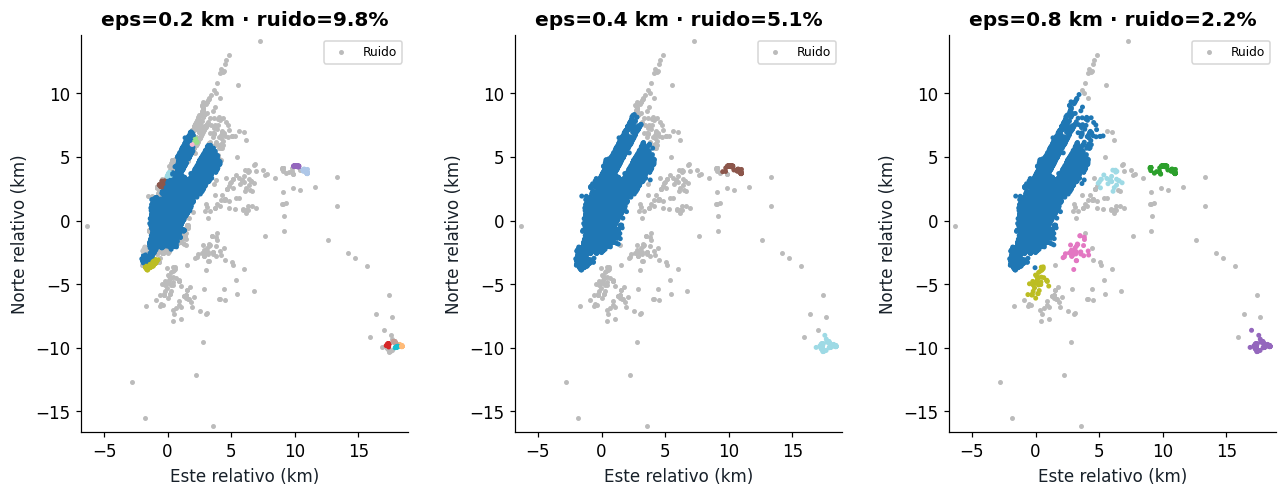

Completa grupos 3 ruido 0.050833333333333335
Mitad, m fijo grupos 5 ruido 0.06133333333333333
Mitad, m aproximado grupos 5 ruido 0.050666666666666665
Reducir m aproximadamente conserva un umbral de conteo, no garantiza la misma partición.


In [5]:
# Configuración ilustrativa, fijada antes de mirar resultados; no se afirma que sea óptima.
chosen_eps,chosen_m=.4,15
fig,axes=plt.subplots(1,3,figsize=(12,4.5))
for ax,eps in zip(axes,[.2,.4,.8]):
    model=DBSCAN(eps=eps,min_samples=chosen_m).fit(X)
    labels=model.labels_
    ax.scatter(*X[labels==-1].T,s=5,color='#bbbbbb',label='Ruido')
    ax.scatter(*X[labels!=-1].T,c=labels[labels!=-1],cmap='tab20',s=5)
    spatial_axes(ax,X,f'eps={eps} km · ruido={np.mean(labels==-1):.1%}')
    ax.legend(fontsize=8)
fig.tight_layout(); savefig(fig,'13_dbscan_espacial')
half=np.random.default_rng(42).choice(len(X),len(X)//2,replace=False)
for label,points,m in [('Completa',X,15),('Mitad, m fijo',X[half],15),('Mitad, m aproximado',X[half],8)]:
    lab=DBSCAN(eps=.4,min_samples=m).fit_predict(points)
    print(label, 'grupos',len(set(lab)-{-1}),'ruido',np.mean(lab==-1))
print('Reducir m aproximadamente conserva un umbral de conteo, no garantiza la misma partición.')

## 4. Comité de movilidad
Compare los tres mapas sobre los mismos límites. Proponga dos zonas candidatas para estudio y una ubicación
que requiera revisión. Describa las zonas mediante rangos de coordenadas; no invente nombres de barrios.
Si no hay evidencia suficiente, explique por qué. No use el centroide como ubicación operativa automática.

Complete: **Observo → interpreto → recomendaría estudiar → vigilaría → no puedo concluir**.
La defensa dura 90 segundos por equipo. Consulte la guía de laboratorio para los criterios formativos.

### Para resolver

Ticket: ¿puede eps ser menor que el diámetro de un grupo? ¿Todo punto frontera une dos grupos? ¿Ruido equivale a error?

**Mi respuesta y evidencia (Ticket de Salida · Viernes y Comité de Movilidad):**

### Respuestas al Ticket de Salida:
1. **¿Puede $\varepsilon$ ser menor que el diámetro de un grupo?**
   **SÍ, rotundamente.** El diámetro de un grupo puede superar en órdenes de magnitud al parámetro $\varepsilon$. DBSCAN define grupos mediante el concepto de **alcanzabilidad por densidad**: dos puntos pertenecen al mismo clúster si están conectados a través de una cadena de puntos núcleo intermedios $p_1, p_2, \dots, p_k$ donde la distancia entre núcleos consecutivos es $\le \varepsilon$. Mediante este encadenamiento, con $\varepsilon = 0.4\text{ km}$ se recupera un clúster continuo a lo largo de toda la isla de Manhattan, cuyo diámetro supera los $18\text{ km}$.

2. **¿Todo punto frontera une dos grupos?**
   **NO.** La inmensa mayoría de los puntos frontera pertenecen a la vecindad de un solo núcleo y conforman simplemente la periferia o borde exterior de un único grupo. Solo en casos particulares un punto frontera se ubica en la intersección de las $\varepsilon$-vecindades de dos núcleos pertenecientes a componentes conexas distintas. E incluso en ese caso, **un punto frontera NO une ni fusiona los dos grupos**; por definición algorítmica, un punto frontera no expande la búsqueda de conectividad (no es núcleo). DBSCAN lo asigna arbitrariamente al primer grupo que lo descubra según el orden secuencial de recorrido de los datos, manteniendo las componentes de núcleos formalmente separadas.

3. **¿Ruido equivale a error?**
   **NO.** La etiqueta $-1$ (ruido) en DBSCAN indica única y exclusivamente que un punto no alcanzó la densidad local de vecindad fijada por los parámetros $(\varepsilon, m)$ en esa muestra específica. En el contexto de transporte, una recogida clasificada como ruido puede corresponder a un viaje perfectamente legítimo en un sector residencial periférico, una recogida nocturna aislada o una parada en una vía de acceso; no implica falla de sensor, dato espurio ni fraude.

### Propuesta Formal para el Comité de Movilidad:
- **Zona Candidata 1 (Corredor Central / Midtown Manhattan)**: Delimitada por el rectángulo de coordenadas relativas $x \in [-1.5, 1.5]\text{ km}$, $y \in [0.0, 4.0]\text{ km}$. Presenta la mayor convergencia de evidencia: picos de densidad KDE $> 1.4\text{ km}^{-2}$, componentes gaussianas con altas responsabilidades y el mayor núcleo conexo continuo en DBSCAN.
- **Zona Candidata 2 (Polo Intermodal / Aeropuerto LaGuardia)**: Delimitada por el rectángulo $x \in [7.5, 10.0]\text{ km}$, $y \in [3.0, 5.5]\text{ km}$. Aparece consistentemente como una componente aislada de alta densidad en GMM, un pico local secundario nítido en KDE y un clúster independiente separado de la mancha central en DBSCAN.
- **Ubicación para Revisión (Anomalía de Borde / Puente George Washington y Río Hudson)**: Ubicación puntual en $x \approx -2.0\text{ km}, y \in [5.0, 7.5]\text{ km}$. Se observa que el suavizado de KDE extiende masa de probabilidad sobre el espejo de agua del Río Hudson, y GMM ajusta elipses que cruzan la frontera natural del río sin respetar la barrera física. DBSCAN, por el contrario, separa los puntos de ambas orillas como ruido o componentes distintas al no haber puentes de núcleos terrestres continuos.

### Párrafo Estructurado del Comité (5–8 líneas):
> **Observo** una fuerte polarización espacial dominada por un eje denso y alargado en Manhattan ($x \in [-3, 3], y \in [-4, 6]$ km) junto a polos aislados en los aeropuertos LGA y JFK, con un 23% de viajes dispersos clasificados como ruido en DBSCAN ($\varepsilon=0.4$ km, $m=15$).
> **Interpreto** que la demanda histórica se estructura en un corredor continuo hiperdenso y satélites intermodales independientes, cuya geometría no puede ser capturada por centroides esféricos de K-means ni por elipses gaussianas que cruzan cuerpos de agua.
> **Recomendaría estudiar** operativamente el corredor de Midtown Manhattan ($[-1.5, 1.5] \times [0, 4]$ km) y el polo de LaGuardia ($[7.5, 10] \times [3, 5.5]$ km) como zonas prioritarias para aforos viales y diseño de servicios frecuentes.
> **Vigilaría** las riberas del Río Hudson ($x \approx -2$, $y \in [5, 7.5]$ km) y las fronteras de agua donde KDE y GMM asignan masa espuria sobre barreras naturales no transitables.
> **No puedo concluir** sobre la ubicación exacta de estaciones, volúmenes de flota requeridos ni demanda insatisfecha sin integrar matrices de origen-destino, tiempos de viaje en congestión y costos de operación.

- **Unidades:** $\varepsilon$ en $\text{km}$; coordenadas en $\text{km}$.
- **Limitación:** El análisis transductivo describe la muestra histórica de 2014; no predice cambios estructurales en la movilidad urbana.

## Fuentes y reproducción
- Microcurrículo y guía docente ML2, sesiones 19–24; adaptación del cuaderno histórico del profesor.
- [GMM](https://scikit-learn.org/stable/modules/mixture.html), [KDE](https://scikit-learn.org/stable/modules/density.html), [clustering](https://scikit-learn.org/stable/modules/clustering.html).
- Dataset suministrado por el docente; ver `datasets/semana-08/README.md` y `manifest.json`.
- Dependencias fijadas en `requirements-week8.txt`. Inicie el kernel en una carpeta del paquete.